# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
2190,12,85,"(0.2714262518980411, 0.6857384251475167)","(-0.108, -0.778, 0.078, 1.057)",1,1.0,"(-0.124, -0.586, 0.1, 0.834)",0.0,1.0,"(-0.135, -0.78, 0.116, 1.102)"
1727,1,69,"(0.1433033517266329, 1.8075969481187537)","(0.008, -0.183, 0.037, 0.11)",1,1.0,"(0.004, 0.002, 0.039, 0.03)",0.0,1.0,"(0.004, -0.183, 0.04, 0.117)"
2098,55,81,"(0.1825292152212203, 0.91730535067745)","(0.216, 0.132, 0.137, 0.481)",1,1.0,"(0.219, 0.32, 0.146, 0.338)",0.0,1.0,"(0.225, 0.13, 0.153, 0.532)"
835,21,31,"(0.202531051367323, 0.357238297754249)","(0.004, -0.262, 0.1, 0.818)",1,1.0,"(-0.001, -0.062, 0.116, 0.425)",0.0,1.0,"(-0.003, -0.267, 0.124, 0.919)"
2389,12,94,"(0.4377652476268179, 0.9729568415243506)","(-0.042, -0.357, 0.043, 0.434)",0,1.0,"(-0.049, -0.548, 0.052, 0.643)",1.0,1.0,"(-0.06, -0.357, 0.065, 0.455)"
...,...,...,...,...,...,...,...,...,...,...
1156,54,46,"(0.5759890361457483, 0.539204361971833)","(-0.276, 0.358, 0.109, -0.8)",0,1.0,"(-0.269, 0.156, 0.093, -0.341)",1.0,1.0,"(-0.266, 0.354, 0.086, -0.712)"
884,8,36,"(0.0299166252862626, 0.5232478091465481)","(0.044, 0.377, -0.064, -0.526)",0,1.0,"(0.051, 0.184, -0.075, -0.279)",0.0,1.0,"(0.055, -0.009, -0.08, -0.035)"
1511,6,61,"(0.0211207957409806, 0.3801931575143365)","(0.003, -0.37, -0.001, 0.758)",0,1.0,"(-0.005, -0.568, 0.014, 1.122)",1.0,1.0,"(-0.016, -0.37, 0.037, 0.763)"
1139,37,46,"(0.5759890361457483, 0.539204361971833)","(-0.161, -0.606, 0.044, 0.422)",0,1.0,"(-0.173, -0.808, 0.052, 0.857)",0.0,1.0,"(-0.189, -1.01, 0.069, 1.295)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
2362,26,93,"(0.2048148528652186, 0.3945260327599418)","(0.03, -0.001, 0.059, 0.102)",1,1.0,"(0.03, 0.198, 0.061, -0.273)",1.0,1.0,"(0.034, 0.397, 0.055, -0.648)",0.030,-0.001,0.059,0.102,0.030,0.198,0.061,-0.273,0.204815,0.394526
2164,15,84,"(0.0433876892251688, 0.5641318888962644)","(-0.0, -0.159, 0.093, 0.414)",1,1.0,"(-0.003, 0.033, 0.102, 0.191)",0.0,1.0,"(-0.003, -0.161, 0.106, 0.466)",-0.000,-0.159,0.093,0.414,-0.003,0.033,0.102,0.191,0.043388,0.564132
2464,15,96,"(0.0424286408799631, 0.4200147402301959)","(-0.068, -0.572, 0.17, 1.118)",1,1.0,"(-0.08, -0.378, 0.192, 0.849)",1.0,1.0,"(-0.087, -0.185, 0.209, 0.59)",-0.068,-0.572,0.170,1.118,-0.080,-0.378,0.192,0.849,0.042429,0.420015
1769,43,69,"(0.1433033517266329, 1.8075969481187537)","(0.299, 1.291, 0.028, -0.31)",1,1.0,"(0.325, 1.476, 0.022, -0.391)",1.0,1.0,"(0.354, 1.662, 0.014, -0.473)",0.299,1.291,0.028,-0.310,0.325,1.476,0.022,-0.391,0.143303,1.807597
1715,0,68,"(0.1632311587418781, 0.2848346616556774)","(-0.002, 0.035, 0.017, 0.013)",0,1.0,"(-0.001, -0.172, 0.018, 0.561)",1.0,1.0,"(-0.004, 0.034, 0.029, 0.033)",-0.002,0.035,0.017,0.013,-0.001,-0.172,0.018,0.561,0.163231,0.284835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754,28,26,"(0.2353791242085411, 0.7095048192803978)","(-0.2, -0.801, 0.174, 1.069)",1,1.0,"(-0.216, -0.611, 0.195, 0.887)",1.0,1.0,"(-0.228, -0.421, 0.213, 0.712)",-0.200,-0.801,0.174,1.069,-0.216,-0.611,0.195,0.887,0.235379,0.709505
1323,4,54,"(0.1888903815857306, 0.5185845731555329)","(-0.043, -0.387, -0.019, 0.564)",0,1.0,"(-0.051, -0.582, -0.008, 0.86)",0.0,1.0,"(-0.063, -0.778, 0.01, 1.159)",-0.043,-0.387,-0.019,0.564,-0.051,-0.582,-0.008,0.860,0.188890,0.518585
1866,35,73,"(0.1621684058210441, 0.4843613270065507)","(0.126, 0.556, -0.112, -0.627)",0,1.0,"(0.137, 0.362, -0.125, -0.351)",1.0,1.0,"(0.144, 0.56, -0.132, -0.707)",0.126,0.556,-0.112,-0.627,0.137,0.362,-0.125,-0.351,0.162168,0.484361
85,11,4,"(0.5781161131451714, 0.3251984731685291)","(0.047, -0.23, 0.066, 1.045)",0,1.0,"(0.042, -0.445, 0.087, 1.782)",0.0,1.0,"(0.033, -0.661, 0.122, 2.531)",0.047,-0.230,0.066,1.045,0.042,-0.445,0.087,1.782,0.578116,0.325198


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
2362,26,93,"(0.2048148528652186, 0.3945260327599418)","(0.03, -0.001, 0.059, 0.102)",1,1.0,"(0.03, 0.198, 0.061, -0.273)",1.0,1.0,"(0.034, 0.397, 0.055, -0.648)",...,-0.001,0.059,0.102,0.030,0.198,0.061,-0.273,0.204815,0.394526,2.0
2164,15,84,"(0.0433876892251688, 0.5641318888962644)","(-0.0, -0.159, 0.093, 0.414)",1,1.0,"(-0.003, 0.033, 0.102, 0.191)",0.0,1.0,"(-0.003, -0.161, 0.106, 0.466)",...,-0.159,0.093,0.414,-0.003,0.033,0.102,0.191,0.043388,0.564132,2.0
2464,15,96,"(0.0424286408799631, 0.4200147402301959)","(-0.068, -0.572, 0.17, 1.118)",1,1.0,"(-0.08, -0.378, 0.192, 0.849)",1.0,1.0,"(-0.087, -0.185, 0.209, 0.59)",...,-0.572,0.170,1.118,-0.080,-0.378,0.192,0.849,0.042429,0.420015,0.0
1769,43,69,"(0.1433033517266329, 1.8075969481187537)","(0.299, 1.291, 0.028, -0.31)",1,1.0,"(0.325, 1.476, 0.022, -0.391)",1.0,1.0,"(0.354, 1.662, 0.014, -0.473)",...,1.291,0.028,-0.310,0.325,1.476,0.022,-0.391,0.143303,1.807597,1.0
1715,0,68,"(0.1632311587418781, 0.2848346616556774)","(-0.002, 0.035, 0.017, 0.013)",0,1.0,"(-0.001, -0.172, 0.018, 0.561)",1.0,1.0,"(-0.004, 0.034, 0.029, 0.033)",...,0.035,0.017,0.013,-0.001,-0.172,0.018,0.561,0.163231,0.284835,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754,28,26,"(0.2353791242085411, 0.7095048192803978)","(-0.2, -0.801, 0.174, 1.069)",1,1.0,"(-0.216, -0.611, 0.195, 0.887)",1.0,1.0,"(-0.228, -0.421, 0.213, 0.712)",...,-0.801,0.174,1.069,-0.216,-0.611,0.195,0.887,0.235379,0.709505,4.0
1323,4,54,"(0.1888903815857306, 0.5185845731555329)","(-0.043, -0.387, -0.019, 0.564)",0,1.0,"(-0.051, -0.582, -0.008, 0.86)",0.0,1.0,"(-0.063, -0.778, 0.01, 1.159)",...,-0.387,-0.019,0.564,-0.051,-0.582,-0.008,0.860,0.188890,0.518585,0.0
1866,35,73,"(0.1621684058210441, 0.4843613270065507)","(0.126, 0.556, -0.112, -0.627)",0,1.0,"(0.137, 0.362, -0.125, -0.351)",1.0,1.0,"(0.144, 0.56, -0.132, -0.707)",...,0.556,-0.112,-0.627,0.137,0.362,-0.125,-0.351,0.162168,0.484361,3.0
85,11,4,"(0.5781161131451714, 0.3251984731685291)","(0.047, -0.23, 0.066, 1.045)",0,1.0,"(0.042, -0.445, 0.087, 1.782)",0.0,1.0,"(0.033, -0.661, 0.122, 2.531)",...,-0.230,0.066,1.045,0.042,-0.445,0.087,1.782,0.578116,0.325198,3.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=1000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.03253576159477234, 0.554315447807312, 0.075...",1.770372,1.099479
1,1,"[0.031961727887392044, 0.5515225529670715, 0.0...",1.753729,1.092283
2,2,"[0.03139583766460419, 0.5487491488456726, 0.07...",1.737254,1.085242
3,3,"[0.030838055536150932, 0.5459941029548645, 0.0...",1.720946,1.078287
4,4,"[0.030288347974419594, 0.5432569980621338, 0.0...",1.704804,1.071407


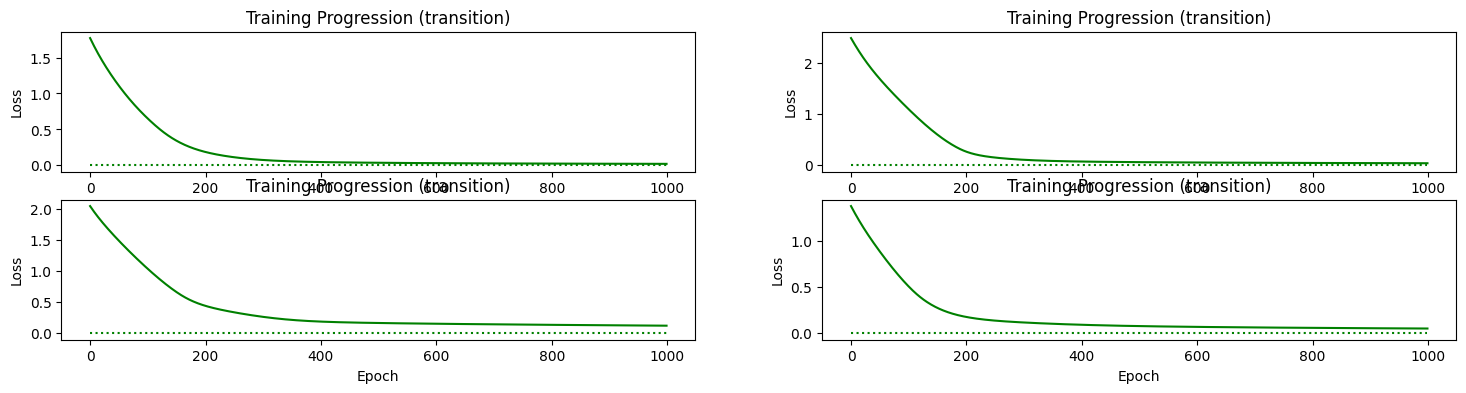

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
2362,26,93,"(0.2048148528652186, 0.3945260327599418)","(0.03, -0.001, 0.059, 0.102)",1,1.0,"(0.03, 0.198, 0.061, -0.273)",1.0,1.0,"(0.034, 0.397, 0.055, -0.648)",...,0.057,0.492242,0.014,0.004,0.028,0.011,0.409242,0.419760,0.565947,0.574018
2164,15,84,"(0.0433876892251688, 0.5641318888962644)","(-0.0, -0.159, 0.093, 0.414)",1,1.0,"(-0.003, 0.033, 0.102, 0.191)",0.0,1.0,"(-0.003, -0.161, 0.106, 0.466)",...,0.185,0.492150,0.005,0.023,0.025,0.132,0.405495,0.423070,0.558753,0.581282
2464,15,96,"(0.0424286408799631, 0.4200147402301959)","(-0.068, -0.572, 0.17, 1.118)",1,1.0,"(-0.08, -0.378, 0.192, 0.849)",1.0,1.0,"(-0.087, -0.185, 0.209, 0.59)",...,0.047,0.480346,0.002,0.019,0.009,0.017,0.404246,0.422373,0.520384,0.574379
1769,43,69,"(0.1433033517266329, 1.8075969481187537)","(0.299, 1.291, 0.028, -0.31)",1,1.0,"(0.325, 1.476, 0.022, -0.391)",1.0,1.0,"(0.354, 1.662, 0.014, -0.473)",...,0.746,0.503876,0.021,0.355,0.012,0.358,0.412157,0.480920,0.527578,0.594849
1715,0,68,"(0.1632311587418781, 0.2848346616556774)","(-0.002, 0.035, 0.017, 0.013)",0,1.0,"(-0.001, -0.172, 0.018, 0.561)",1.0,1.0,"(-0.004, 0.034, 0.029, 0.033)",...,0.242,0.485328,0.007,0.014,0.012,0.209,0.406328,0.421502,0.527578,0.585905


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    # print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

,best_rse
count,2504.000000
mean,0.195672
std,0.237106
min,0.005000
25%,0.084000
50%,0.140000
75%,0.234000
max,4.654000


# LOOP

In [ ]:

# while True: 
for i in range(50): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'({i}) epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1496
best_rse    0.116728
dtype: float64
epis_changed: 1568
best_rse    0.082574
dtype: float64
epis_changed: 1468
best_rse    0.068561
dtype: float64
epis_changed: 1580
best_rse    0.061503
dtype: float64
epis_changed: 1616
best_rse    0.052951
dtype: float64
epis_changed: 1733
best_rse    0.045196
dtype: float64
epis_changed: 1782
best_rse    0.042462
dtype: float64
epis_changed: 1756
best_rse    0.039956
dtype: float64
epis_changed: 1749
best_rse    0.036683
dtype: float64
epis_changed: 1749
best_rse    0.034322
dtype: float64
epis_changed: 1758
best_rse    0.032615
dtype: float64
epis_changed: 1758
best_rse    0.031475
dtype: float64
epis_changed: 1758
best_rse    0.03076
dtype: float64
epis_changed: 1765
best_rse    0.030183
dtype: float64
epis_changed: 1765
best_rse    0.029743
dtype: float64
epis_changed: 1765
best_rse    0.029363
dtype: float64
epis_changed: 1765
best_rse    0.029067
dtype: float64
epis_changed: 1746
best_rse    0.028914
dtype: float64
epis_change

# Export Model 

In [ ]:
import pickle

exp = {
    "data": prediction_dataset,
    "model": models 
}

nome_do_arquivo = 'kmodels.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)